CWD = /home/clara/Research/fyp_fl_smart_home
[OK] Loaded results/casas_fedavg_r50.csv, rounds=50
[OK] Loaded results/casas_fedprox_r50.csv, rounds=50
[OK] Loaded results/casas_scaffold_r50.csv, rounds=50
[OK] Loaded results/casas_feddc_r50.csv, rounds=50


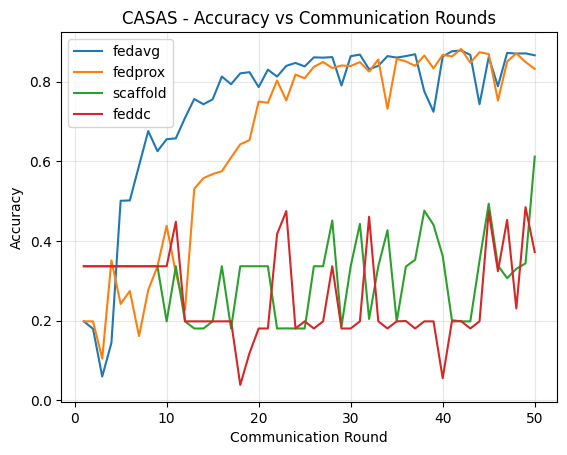

[SAVED] results/plots/casas_compare_accuracy.png


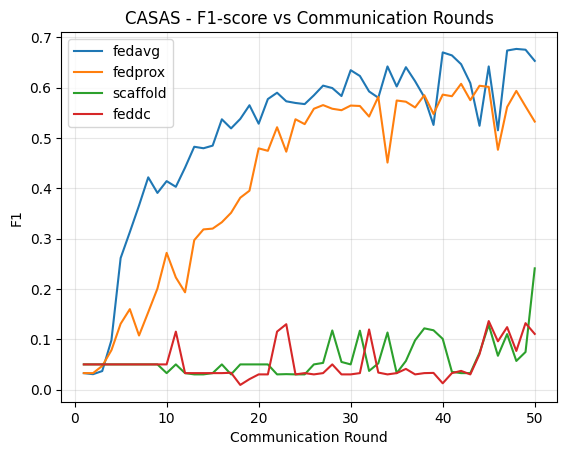

[SAVED] results/plots/casas_compare_f1.png


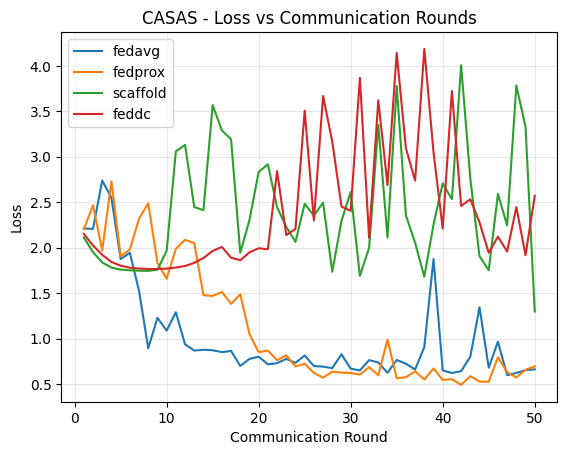

[SAVED] results/plots/casas_compare_loss.png


In [1]:
import os
os.chdir("/home/clara/Research/fyp_fl_smart_home")
print("CWD =", os.getcwd())
import pandas as pd
import matplotlib.pyplot as plt



RESULTS_DIR = "results"
PLOTS_DIR = os.path.join(RESULTS_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

ALGOS = ["fedavg", "fedprox", "scaffold", "feddc"]
DATASET = "casas"   

dfs = {}

for algo in ALGOS:
    csv_path = os.path.join(RESULTS_DIR, f"{DATASET}_{algo}_r50.csv")
    if not os.path.exists(csv_path):
        print(f"[WARN] 找不到 {csv_path}")
        continue

    df = pd.read_csv(csv_path)
    df["round"] = df["round"].astype(int)
    for col in ["loss", "accuracy", "f1"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    dfs[algo] = df
    print(f"[OK] Loaded {csv_path}, rounds={df['round'].max()}")

if len(dfs) < 2:
    raise RuntimeError("至少需要 2 个算法 CSV 才能画对比图")

# -------- 画图函数 --------
def plot_metric(metric: str, title: str, out_name: str):
    plt.figure()
    for algo, df in dfs.items():
        plt.plot(df["round"], df[metric], label=algo)
    plt.xlabel("Communication Round")
    plt.ylabel(metric.capitalize())
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    out_path = os.path.join(PLOTS_DIR, out_name)
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"[SAVED] {out_path}")

# -------- 三张论文图 --------
plot_metric(
    "accuracy",
    f"{DATASET.upper()} - Accuracy vs Communication Rounds",
    f"{DATASET}_compare_accuracy.png",
)

plot_metric(
    "f1",
    f"{DATASET.upper()} - F1-score vs Communication Rounds",
    f"{DATASET}_compare_f1.png",
)

plot_metric(
    "loss",
    f"{DATASET.upper()} - Loss vs Communication Rounds",
    f"{DATASET}_compare_loss.png",
)

In [2]:
#casas iid
import os
import pandas as pd

# =========================
# 1️⃣ 项目根目录（⚠️ 必须是绝对路径）
# =========================
BASE = "/home/clara/Research/fyp_fl_smart_home"

# =========================
# 2️⃣ 手动指定 CSV（你完全可控）
#    ⚠️ 文件名必须真实存在
# =========================

CSV_MAP = {
    "fedavg":   os.path.join(BASE, "results/casas_fedavg_r50_20260115_100840.csv"),
    "fedprox":  os.path.join(BASE, "results/casas_fedprox_r50_20260115_102459.csv"),
    "scaffold": os.path.join(BASE, "results/casas_scaffold_r50_20260115_103911.csv"),
    "feddc":    os.path.join(BASE, "results/casas_feddc_r50_20260115_105538.csv"),
}

# =========================
# 3️⃣ 读取 CSV（带安全检查）
# =========================
def load_csv(fp: str) -> pd.DataFrame:
    if not os.path.exists(fp):
        raise FileNotFoundError(f"❌ CSV not found: {fp}")

    df = pd.read_csv(fp)

    # 标准化列
    df["round"] = df["round"].astype(int)
    for col in ["loss", "accuracy", "f1"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # 清理 & 排序
    df = (
        df.dropna(subset=["loss", "accuracy", "f1"])
          .sort_values("round")
          .reset_index(drop=True)
    )
    return df

# =========================
# 4️⃣ 汇总（默认：最后一轮）
# =========================
rows = []

for algo, fp in CSV_MAP.items():
    df = load_csv(fp)

    last_row = df.iloc[-1]   # 最后一轮
    rows.append({
        "Algorithm": algo.upper(),
        "Round_used": int(last_row["round"]),
        "Accuracy": round(float(last_row["accuracy"]), 4),
        "F1-score": round(float(last_row["f1"]), 4),
        "Loss": round(float(last_row["loss"]), 4),
        "CSV_file": os.path.basename(fp),
    })

summary_df = (
    pd.DataFrame(rows)
      .sort_values("Algorithm")
      .reset_index(drop=True)
)

# =========================
# 5️⃣ 输出
# =========================
print("\n=== Federated Learning Final Performance Summary ===\n")
display(summary_df)


=== Federated Learning Final Performance Summary ===



,Algorithm,Round_used,Accuracy,F1-score,Loss,CSV_file
0,FEDAVG,50,0.8625,0.6343,0.6384,casas_fedavg_r50_20260115_100840.csv
1,FEDDC,50,0.1978,0.0330,2.4165,casas_feddc_r50_20260115_105538.csv
2,FEDPROX,50,0.8645,0.5868,0.6006,casas_fedprox_r50_20260115_102459.csv
3,SCAFFOLD,50,0.1984,0.0432,1.8220,casas_scaffold_r50_20260115_103911.csv
